## Run_QLC_nonDim

This code solves the non-dimensionalized QLC problem. Parameters include:

- $\overline N$, and $N^*$ (atomistic-level characteristics of the ice QLL thicknesses)
- $\sigma_o$ (difference in equilibrium supersaturation between microsurfaces I and II)
- $h_{pr}$ (thickness of a prismatic facet monolayer)
- $D_{surf}$ (surface diffusion coefficient of the QLL)
- $\nu_{kin}$ (kinetic velocity -- the rate at which water vapor strikes the surface)
- $L$ (physical length of the facet surface)
- $nx_{crystal}$ (number of discrete points used to represent the surface)
- $L$ (crystal dimension)
- $\sigma_{I,corner}$ (imposed supersaturation at the facet corner)
- $c_r$ (relative reduction in supersaturation at facet centers relative to corners, in fraction and %)
- $t_{eq}$ (time constant for ice/QLL freezing/thawing)

In [2]:
from pint import UnitRegistry; AssignQuantity = UnitRegistry().Quantity
import numpy as np
import matplotlib.pylab as plt
from matplotlib.animation import FuncAnimation
import QLC_nonDim as QLC_nonDim
import f90nml

In [3]:
%matplotlib inline
from IPython.display import HTML

In [4]:
# This is for plotting a single function with matplotlib.pyplot
def plot_alone(ylist, xlist, label = ""):
    plt.figure()
    plt.plot(xlist,ylist,label=label)
    plt.xlabel('x (micrometers)')
    plt.grid(True)
    plt.legend()

In [5]:
# Specify the input file
inputfile = "GI parameters - Reference limit cycle.nml"

# Solve the PDE
runtime = 200
val1 = QLC_nonDim.generate_reference_solution(inputfile = inputfile, runtime=runtime)

Using parameter file GI parameters - Reference limit cycle.nml ...

This is a run from time 0.0 millisecond to 200.0 millisecond
dt = 4081.6326530612246 microsecond
10 % elapsed time is 0.026 minutes
20 % elapsed time is 0.049 minutes
30 % elapsed time is 0.072 minutes
40 % elapsed time is 0.094 minutes
50 % elapsed time is 0.117 minutes
60 % elapsed time is 0.140 minutes
70 % elapsed time is 0.164 minutes
80 % elapsed time is 0.187 minutes
90 % elapsed time is 0.210 minutes
100% done
status =  0
message =  The solver successfully reached the end of the integration interval.
['message', 'nfev', 'njev', 'nlu', 'sol', 'status', 'success', 't', 't_events', 'y', 'y_events']


3 50 320
50 320


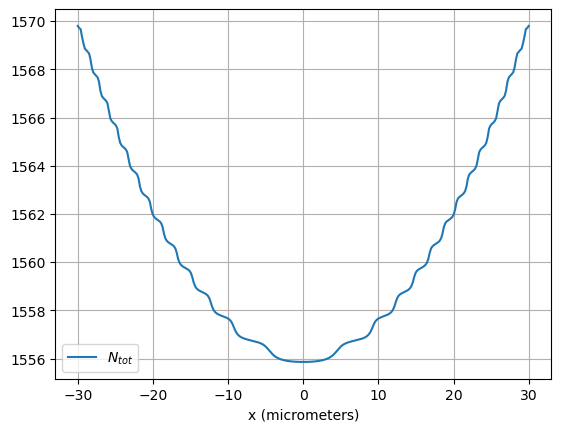

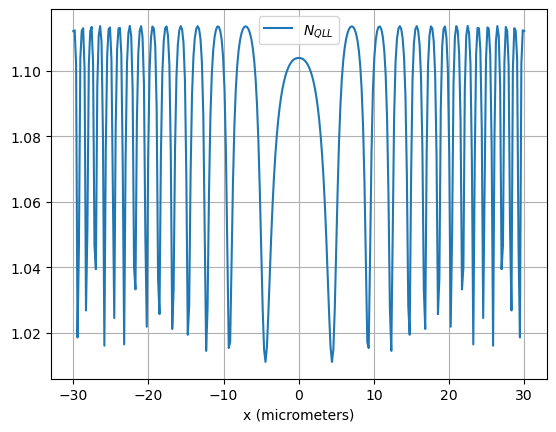

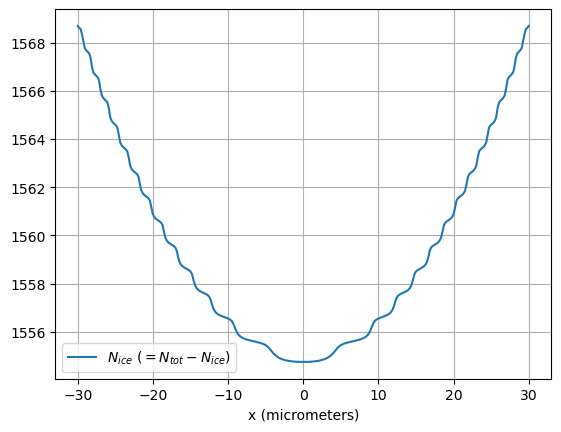

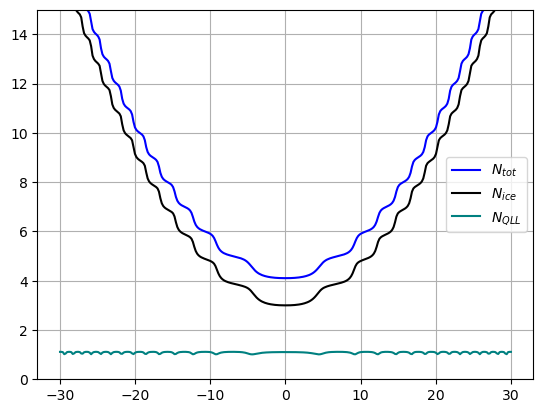

In [6]:
# Dimensionalized spatial information we want for plotting
GI=f90nml.read(inputfile)['GI']
L = GI['L']
nobj, ntimes, nx = np.shape(val1); print(nobj, ntimes, nx)
times = np.linspace(0,runtime,ntimes)
x_QLC = np.linspace(-L,L,nx)

ntimes, nx_crystal = np.shape(val1[0]); print(ntimes,nx_crystal)
x_QLC = np.linspace(-L,L,nx_crystal)

# Plotting the solution
itime = -1 # This specifies which time index we want (-1 => last one)
plot_alone(val1[0][itime], x_QLC, "$N_{tot}$")
plot_alone(val1[1][itime], x_QLC, "$N_{QLL}$")
plot_alone(val1[2][itime], x_QLC, "$N_{ice}$ ($ = N_{tot}-N_{ice}$)")

plt.figure()
ixmid = round(nx_crystal/2)
itime = -1
yoffset = 3

ytot = val1[0][itime] -val1[2][itime][ixmid]+yoffset
plt.plot(x_QLC,ytot,'blue',label="$N_{tot}$")

yice = val1[2][itime] -val1[2][itime][ixmid]+yoffset
plt.plot(x_QLC,yice,'k',label="$N_{ice}$")

yQLL = val1[1][itime]
plt.plot(x_QLC,yQLL,'teal',label="$N_{QLL}$")

plt.grid(True)
plt.ylim([0,15])
plt.legend()

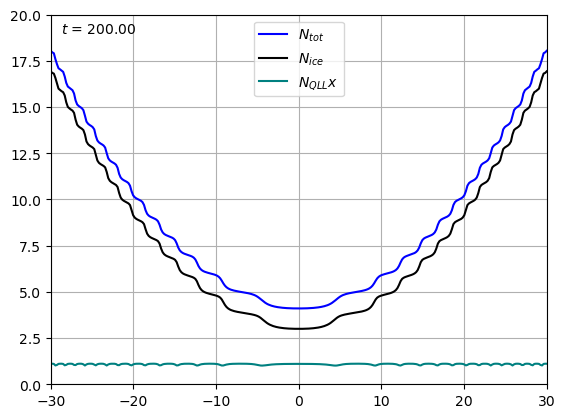

In [7]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()

ixmid = round(nx_crystal / 2)
yoffset = 3
ymax = 20

# Initial frame
ytot = val1[0][0] - val1[2][0][ixmid] + yoffset
yice = val1[2][0] - val1[2][0][ixmid] + yoffset
yQLL = val1[1][0]

line_tot, = ax.plot(x_QLC, ytot, 'blue', label="$N_{tot}$")
line_ice, = ax.plot(x_QLC, yice, 'k', label="$N_{ice}$")
line_qll, = ax.plot(x_QLC, yQLL*10, 'teal', label="$N_{QLL} x$")

ax.set_xlim(x_QLC.min(), x_QLC.max())
ax.set_ylim(0, ymax)
ax.grid(True)
ax.legend()

time_text = ax.text(
    0.02, 0.95, "",
    transform=ax.transAxes
)

def update(itime):
    ytot = val1[0][itime] - val1[2][itime][ixmid] + yoffset
    yice = val1[2][itime] - val1[2][itime][ixmid] + yoffset
    yQLL = val1[1][itime]

    line_tot.set_ydata(ytot)
    line_ice.set_ydata(yice)
    line_qll.set_ydata(yQLL)

    time_text.set_text(f"$t$ = {times[itime]:.2f}")

    return line_tot, line_ice, line_qll, time_text

ani = FuncAnimation(
    fig,
    update,
    frames=ntimes,
    interval=100,
    blit=True
)

HTML(ani.to_jshtml())

In [8]:
ani.save(
    "QLC2_evolution.gif",
    writer="pillow",
    fps=10,
    dpi=150
)